# Creating micrograd

In [80]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

function applied on each element

## creating a class
- `__abc__` is an operator

In [81]:
class Value:
    def __init__(self, data):
        self.data = data
    def __repr__(self):
        return f'Value(data={self.data})'
a = Value(2.0)
b = Value(-3.0)
a+b

TypeError: unsupported operand type(s) for +: 'Value' and 'Value'

this error because the operator is not defined for 'value'

In [101]:
class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')
    
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
      
    return out
  
  def __rmul__(self, other):
    return self * other

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    
    return out
  
  def backward(self):
    
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()


In [90]:
# visualize the graph
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # left to right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rect box node for it
        dot.node(name= uid, label = "%s | {data %.4f} | {grad %.4f}" % (n.label, n.data, n.grad), shape = "record")
        if n._op:
            dot.node(name = uid + n._op, label = n._op) # if this val is a result of an operation, create an op node for it
            dot.edge(uid + n._op, uid) # connect this node to it
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [91]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

b = Value(6.8813, label='b')

x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

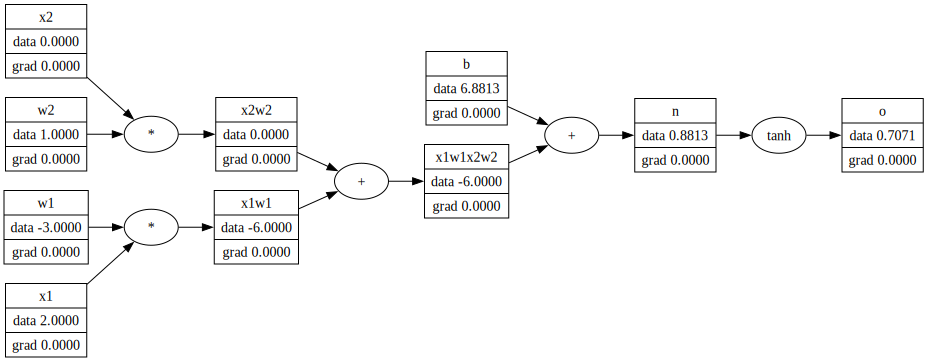

In [92]:
draw_dot(o)

### Bugs

#### 1. We used += in the functions in Value() instead of just =
This is because the gradiants are accumilative; meaning that across epochs, they accumilate and therefore need to be additively updates as we go through epochs. Below are some examples where we address them, which would have otherwise failed

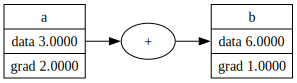

In [93]:
a = Value(3.0, label='a')
b = a + a
b.label = 'b'
b.backward()
draw_dot(b)

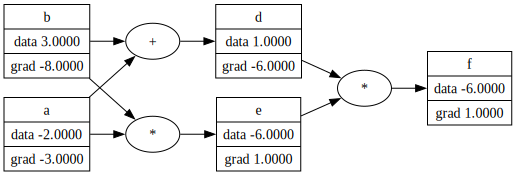

In [94]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a + b; d.label = 'd'
e = a * b; e.label = 'e'
f = d * e; f.label = 'f'
f.backward()
draw_dot(f)

In [102]:
a = Value(2.0)
a + 1; a * 2

Value(data=4.0)

In [103]:
2 * a

Value(data=4.0)